In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [3]:
df = pd.read_csv("data.csv")

In [4]:
df.columns

Index(['Unnamed: 0', 'Nation', 'Survey_Year', 'Country_Category',
       'Mortality_Adults', 'Infant_Deaths_Count', 'Alcohol_Consumption_Rate',
       'Expenditure_Percentage_GDP', 'Hepatitis_B_Vaccination_Coverage',
       'Measles_Infection_Count', 'Body_Mass_Index_Avg',
       'Polio_Vaccination_Coverage', 'Total_Health_Expenditure',
       'Diphtheria_Vaccination_Coverage', 'HIV_AIDS_Prevalence_Rate',
       'Gross_Domestic_Product', 'Total_Population', 'Thinness',
       'Life_Expectancy_Years'],
      dtype='object')

In [5]:
df.head()

,Unnamed: 0,Nation,Survey_Year,Country_Category,Mortality_Adults,Infant_Deaths_Count,Alcohol_Consumption_Rate,Expenditure_Percentage_GDP,Hepatitis_B_Vaccination_Coverage,Measles_Infection_Count,Body_Mass_Index_Avg,Polio_Vaccination_Coverage,Total_Health_Expenditure,Diphtheria_Vaccination_Coverage,HIV_AIDS_Prevalence_Rate,Gross_Domestic_Product,Total_Population,Thinness,Life_Expectancy_Years
0,0,Syrian Arab Republic,2006.0,Developing,123.0,8,0.97,122.652333,83.0,517.0,48.5,83.0,3.78,8.0,0.1,1762.246170,18914977.0,6.4,73.7
1,1,Croatia,2006.0,Developed,113.0,0,11.83,1555.651986,NaN,1.0,58.1,96.0,6.95,96.0,0.1,11363.418450,444.0,1.8,75.9
2,2,Montenegro,2007.0,Developing,125.0,0,4.98,678.518894,9.0,0.0,57.2,92.0,6.74,92.0,0.1,5957.145693,615875.0,2.1,74.2
3,3,Bahrain,2014.0,Developing,7.0,0,1.57,367.255674,98.0,46.0,62.9,98.0,4.98,98.0,0.1,24983.379200,NaN,6.1,76.8
4,4,Kenya,2000.0,Developing,428.0,77,1.51,0.681686,NaN,21002.0,14.4,8.0,4.68,82.0,18.1,43.979713,3145483.0,9.2,51.9


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        2938 non-null   int64  
 1   Nation                            2937 non-null   object 
 2   Survey_Year                       2936 non-null   float64
 3   Country_Category                  2935 non-null   object 
 4   Mortality_Adults                  2925 non-null   float64
 5   Infant_Deaths_Count               2938 non-null   int64  
 6   Alcohol_Consumption_Rate          2744 non-null   float64
 7   Expenditure_Percentage_GDP        2938 non-null   float64
 8   Hepatitis_B_Vaccination_Coverage  2385 non-null   float64
 9   Measles_Infection_Count           2936 non-null   float64
 10  Body_Mass_Index_Avg               2904 non-null   float64
 11  Polio_Vaccination_Coverage        2919 non-null   float64
 12  Total_

In [7]:
df.describe()

,Unnamed: 0,Survey_Year,Mortality_Adults,Infant_Deaths_Count,Alcohol_Consumption_Rate,Expenditure_Percentage_GDP,Hepatitis_B_Vaccination_Coverage,Measles_Infection_Count,Body_Mass_Index_Avg,Polio_Vaccination_Coverage,Total_Health_Expenditure,Diphtheria_Vaccination_Coverage,HIV_AIDS_Prevalence_Rate,Gross_Domestic_Product,Total_Population,Thinness,Life_Expectancy_Years
count,2938.000000,2936.00000,2925.000000,2938.000000,2744.000000,2938.000000,2385.000000,2936.000000,2904.000000,2919.000000,2711.000000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2928.000000
mean,1468.500000,2007.52282,164.865299,30.303948,4.602861,738.251295,80.940461,2420.752384,38.321247,82.550188,5.938359,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,69.224932
std,848.271871,4.61257,124.316868,117.926501,4.052413,1987.914858,25.070016,11471.077443,20.044034,23.428046,2.498765,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,9.523867
min,0.000000,2000.00000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,36.300000
25%,734.250000,2004.00000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,78.000000,4.260000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,63.100000
50%,1468.500000,2008.00000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,93.000000,5.760000,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,72.100000
75%,2202.750000,2012.00000,228.000000,22.000000,7.702500,441.534144,97.000000,358.750000,56.200000,97.000000,7.495000,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,75.700000
max,2937.000000,2015.00000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,99.000000,17.600000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,89.000000


In [8]:
df = df.drop(columns=["Unnamed: 0"], axis=1)
df = df.dropna(subset=["Nation","Life_Expectancy_Years"])
df["Survey_Year"] = df["Survey_Year"].fillna(df["Survey_Year"].median()) # we can also use inplace = True
df["Country_Category"] = df["Country_Category"].fillna(df["Country_Category"].mode()[0])

In [9]:
replaced_with_median = ["Mortality_Adults", "Alcohol_Consumption_Rate",
                        "Hepatitis_B_Vaccination_Coverage",
                        "Measles_Infection_Count",
                        "Body_Mass_Index_Avg",
                        "Polio_Vaccination_Coverage",
                        "Total_Health_Expenditure",
                        "Diphtheria_Vaccination_Coverage",
                        "Thinness", "Gross_Domestic_Product",
                        "Total_Population"]

for i in replaced_with_median:
    df[i] = df[i].fillna(df[i].median())

In [10]:
df.info() # after cleaning

<class 'pandas.core.frame.DataFrame'>
Index: 2927 entries, 0 to 2937
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Nation                            2927 non-null   object 
 1   Survey_Year                       2927 non-null   float64
 2   Country_Category                  2927 non-null   object 
 3   Mortality_Adults                  2927 non-null   float64
 4   Infant_Deaths_Count               2927 non-null   int64  
 5   Alcohol_Consumption_Rate          2927 non-null   float64
 6   Expenditure_Percentage_GDP        2927 non-null   float64
 7   Hepatitis_B_Vaccination_Coverage  2927 non-null   float64
 8   Measles_Infection_Count           2927 non-null   float64
 9   Body_Mass_Index_Avg               2927 non-null   float64
 10  Polio_Vaccination_Coverage        2927 non-null   float64
 11  Total_Health_Expenditure          2927 non-null   float64
 12  Diphtheria_

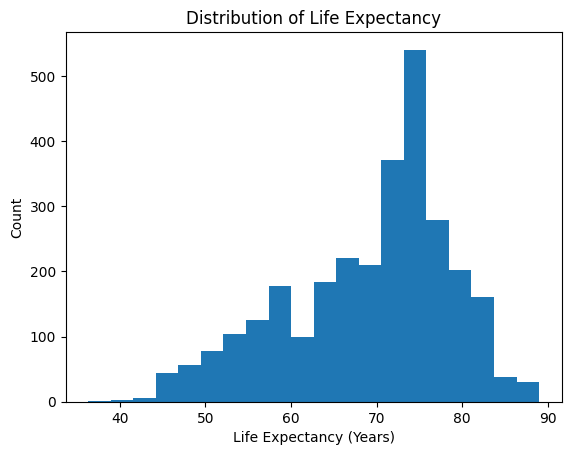

In [11]:
plt.figure()
plt.hist(df['Life_Expectancy_Years'], bins=20)
plt.xlabel("Life Expectancy (Years)")
plt.ylabel("Count")
plt.title("Distribution of Life Expectancy")
plt.show()


the figure shows that Life_Expectancy_Years is negative skew (left-skewed distribution) and most values are between 70 and 80 years

<Figure size 640x480 with 0 Axes>

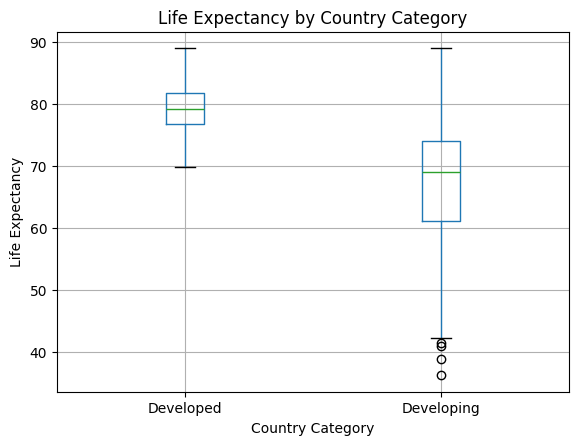

In [12]:
plt.figure()
df.boxplot(column='Life_Expectancy_Years', by='Country_Category')
plt.title('Life Expectancy by Country Category')
plt.suptitle('')
plt.xlabel('Country Category')
plt.ylabel('Life Expectancy')
plt.show()

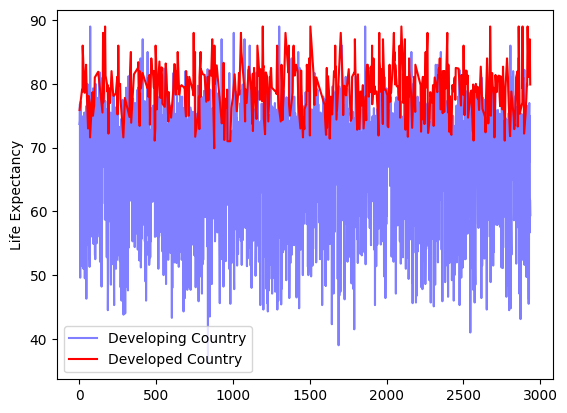

In [13]:
developed_life = df.loc[
    df['Country_Category'] == 'Developed',
    'Life_Expectancy_Years'
].dropna()

developing_life = df.loc[
    df['Country_Category'] == 'Developing',
    'Life_Expectancy_Years'
].dropna()

plt.figure()
plt.plot(developing_life, label="Developing Country", color="blue", alpha=0.5)
plt.plot(developed_life, label="Developed Country", color="red")
plt.ylabel("Life Expectancy")
plt.legend()
plt.show()

From the last two figures, Developed countries have higher Life_Expectancy_Years than developing countries, 
with higher median values and lower variability compared to developing countries.

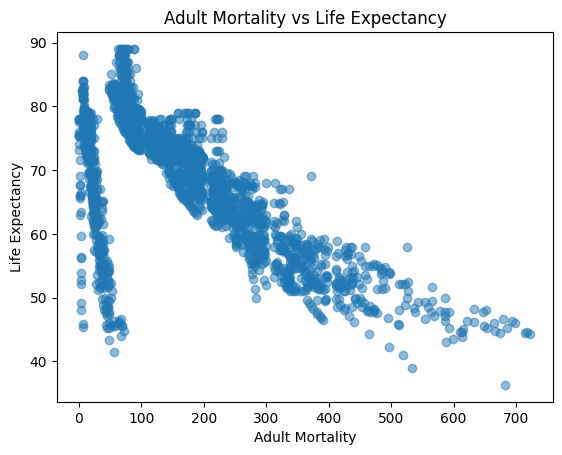

In [14]:
plt.figure()
plt.scatter(df["Mortality_Adults"], df["Life_Expectancy_Years"], alpha=0.5)
plt.title("Adult Mortality vs Life Expectancy")
plt.xlabel("Adult Mortality")
plt.ylabel("Life Expectancy")
plt.show()

The figure shows a negative relationship between Adult Mortality and Life Expectancy.

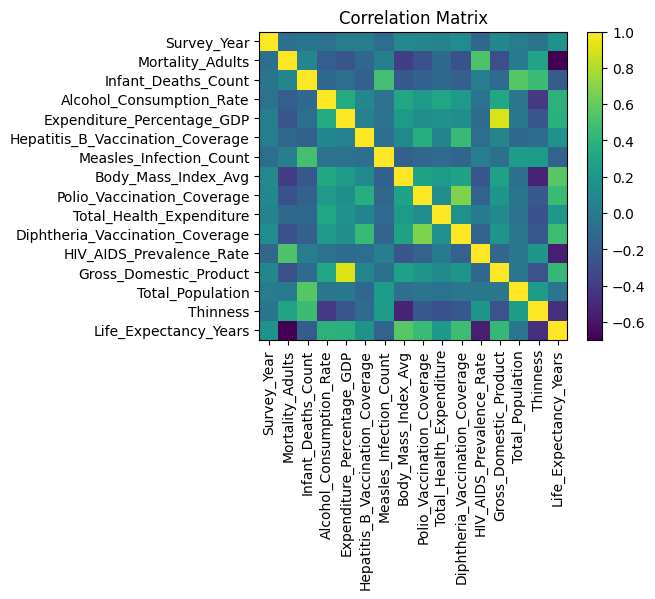

In [15]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(5,4))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Correlation Matrix")
plt.show()


The correlation heatmap shows the strength and direction of the relationships between all numerical features in the dataset.

In [16]:
corr['Life_Expectancy_Years'].sort_values()

Mortality_Adults                   -0.696113
HIV_AIDS_Prevalence_Rate           -0.556626
Thinness                           -0.468123
Infant_Deaths_Count                -0.196604
Measles_Infection_Count            -0.157622
Total_Population                   -0.028867
Survey_Year                         0.168990
Hepatitis_B_Vaccination_Coverage    0.171348
Total_Health_Expenditure            0.209558
Expenditure_Percentage_GDP          0.381837
Alcohol_Consumption_Rate            0.390602
Gross_Domestic_Product              0.430957
Polio_Vaccination_Coverage          0.459576
Diphtheria_Vaccination_Coverage     0.473388
Body_Mass_Index_Avg                 0.558818
Life_Expectancy_Years               1.000000
Name: Life_Expectancy_Years, dtype: float64

In [17]:
target_col = 'Life_Expectancy_Years'
dropped_cols = ["Total_Health_Expenditure", "Hepatitis_B_Vaccination_Coverage", 
               "Survey_Year", "Total_Population", "Measles_Infection_Count",
               "Infant_Deaths_Count", "Country_Category", "Nation", target_col]

X = df.drop(columns=dropped_cols)
y = df[target_col]

In [18]:
x_train, x_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
print(X.shape,y.shape)

(2927, 9) (2927,)


In [ ]:
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

model.fit(x_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=3, min_samples_split=5,
                      n_estimators=500, n_jobs=-1, random_state=42)

In [21]:
y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)   
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 4.037837506626049
RMSE: 2.0094371118863235
R²: 0.956449401459037
